# E7: Subpopulation discrimination (simulated data)

**Started:** January 21, 2026

**Last updated:** January 28, 2026

**Research question:** What ratio of dimensions needs to show subpopulation trends for anchored GOT to match them correctly?

**Hypothesis:** 20% or less of dimensions need to show subpopulation discrimination for anchored GOT to match them correctly.

**Conclusion:** 20% or more of dimensions need to show moderate subpopulation discrimination for GOT to match them. Sublabel accuracy does not appear to be affected by noise dimensions, but overall class accuracy is.

**Potential Next Steps:** Investigate the same trends with graph geodesic distances, which posed issues in this notebook. Explore how class and sublabel accuracy is influenced by discrepancies between source and target generative distributions.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sp
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import ot
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from speciesot_simulation_helpers import generate_point_clouds, \
                              plot_first_two_dims, \
                              resample_point_clouds, \
                              flatten_clouds, \
                              run_ot, \
                              compute_mapping_acc, \
                              knn_geodesic_distance_matrix, \
                              plot_knn_graph, \
                              plot_got_best_matches_with_labels, \
                              gw_seeded, \
                              generate_point_clouds_subpops, \
                              resample_point_clouds_subpops, \
                              sublabel_match_rate_from_gw
                              

In [2]:
num_clouds = 5
num_points_per_cloud = 20
num_dims = 50
num_disc_dims=25

In [3]:
clouds1, means1, covs1, poplabels1, sublabels1 = generate_point_clouds_subpops(num_clouds, 
                                                                               num_points_per_cloud, 
                                                                               num_dims, 
                                                                               A=2, 
                                                                               B=0.5, 
                                                                               P_disc=num_disc_dims, 
                                                                               SP=2, 
                                                                               disc_pops=[0],
                                                                               discriminative_strength=2)

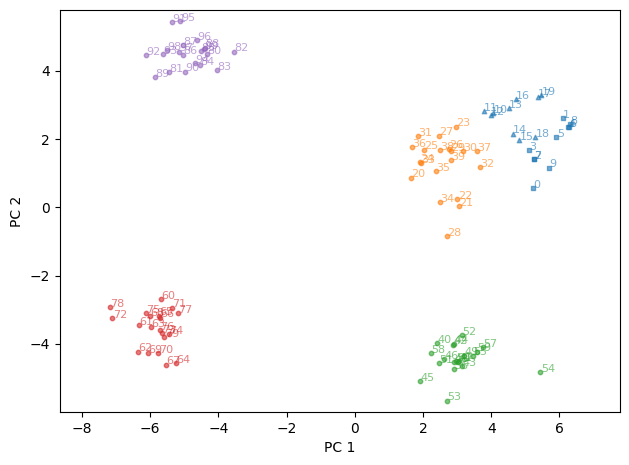

In [4]:
plot_first_two_dims(clouds1, sublabels=sublabels1, annotate=True, pca=True)

In [5]:
clouds2, poplabels2, sublabels2 = resample_point_clouds(means1, covs1, num_points_per_cloud,
    P_disc=10, SP=2, disc_pops=[0],
    discriminative_strength=4)

TypeError: resample_point_clouds() got an unexpected keyword argument 'P_disc'

In [ ]:
plot_first_two_dims(clouds2, sublabels=sublabels2, annotate=True, pca=True)

In [ ]:
cloud_coords1, labels1 = flatten_clouds(clouds1)
cloud_coords2, labels2 = flatten_clouds(clouds2)

In [23]:
#gw = run_ot(cloud_coords1, cloud_coords2, num_clouds * num_points_per_cloud)

In [24]:
gws = gw_seeded(cloud_coords1, cloud_coords2, num_clouds * num_points_per_cloud, [87], [86], distance_method="euclidean")

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'GOT argmax matches with class consistency'}, xlabel='dim 0', ylabel='dim 1'>,
 array([12,  1,  9, 18, 16, 15, 19, 14, 13,  2,  0,  5, 10,  6,  4, 11,  7,
         8, 17,  3, 29, 20, 22, 33, 26, 37, 32, 28, 27, 36, 38, 31, 34, 21,
        24, 30, 39, 35, 23, 25, 49, 52, 46, 58, 55, 59, 45, 43, 40, 48, 56,
        50, 47, 54, 57, 51, 44, 42, 41, 53, 64, 76, 71, 73, 65, 67, 60, 62,
        61, 78, 63, 75, 72, 70, 77, 66, 74, 68, 69, 79, 89, 88, 94, 84, 83,
        99, 93, 86, 80, 96, 91, 82, 98, 97, 85, 90, 81, 95, 87, 92]),
 array([0.01      , 0.01      , 0.01      , 0.01      , 0.01      ,
        0.01      , 0.01      , 0.01      , 0.01      , 0.01      ,
        0.01      , 0.01      , 0.01      , 0.01      , 0.01      ,
        0.01      , 0.01      , 0.01      , 0.01      , 0.01      ,
        0.01      , 0.01      , 0.01      , 0.01      , 0.01      ,
        0.01      , 0.01      , 0.01      , 0.01      , 0.00999999,
  

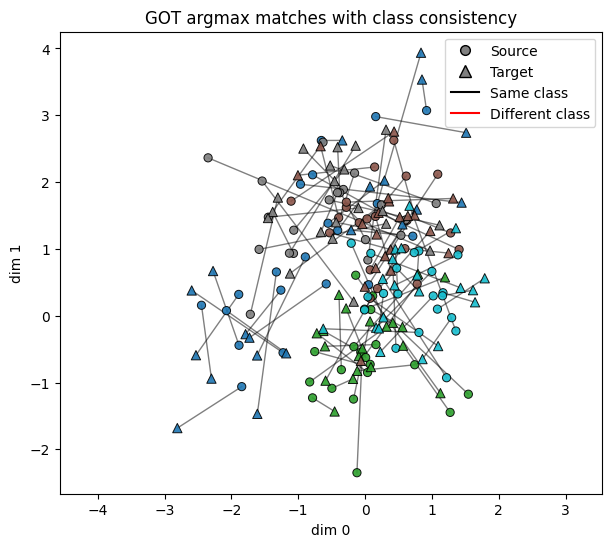

In [25]:
plot_got_best_matches_with_labels(cloud_coords1, cloud_coords2, gws, labels1, labels2)

In [27]:
sublabel_match_rate_from_gw(gws, labels1, labels2, sublabels1, sublabels2)

1.0

In [28]:
# 60% match rate with 2 dims, 

In [29]:
sublabels1

array([[2, 2, 1, 2, 2, 2, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 2, 1, 2, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [30]:
gws.shape

(100, 100)

### Relationship between discriminatory dimensions and accuracy

In [3]:
num_clouds = 5
num_points_per_cloud = 20
num_dims = 50

In [4]:
disc_dim_arr = []
disc_dim_acc_arr = []
distance_method_arr = []
for distance_method in ['euclidean']:
    for disc_dims in [2,5,10,25,50]:
        fully_paired_examples = 0
        while fully_paired_examples < 3:
            clouds1, means1, covs1, poplabels1, sublabels1 = generate_point_clouds_subpops(num_clouds, 
                                                                                       num_points_per_cloud, 
                                                                                       num_dims, 
                                                                                       A=2, 
                                                                                       B=0.5, 
                                                                                       P_disc=disc_dims, 
                                                                                       SP=2, 
                                                                                       disc_pops=[0],
                                                                                       discriminative_strength=2)
            clouds2, poplabels2, sublabels2 = resample_point_clouds_subpops(means1, covs1, num_points_per_cloud,
                                                                    P_disc=disc_dims, SP=2, disc_pops=[0],
                                                                    discriminative_strength=2)
            cloud_coords1, labels1 = flatten_clouds(clouds1)
            cloud_coords2, labels2 = flatten_clouds(clouds2)

            gw = run_ot(cloud_coords1, cloud_coords2, num_clouds * num_points_per_cloud, 
                        distance_method=distance_method)

            acc = compute_mapping_acc(gw, labels1, labels2)

            print(acc)

            if acc > 0.6:
                fully_paired_examples += 1

                sublabel_acc = sublabel_match_rate_from_gw(gw, labels1, labels2, sublabels1, sublabels2)

                disc_dim_arr.append(disc_dims)
                disc_dim_acc_arr.append(sublabel_acc)
                distance_method_arr.append(distance_method)
    

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


0.6
0.6
1.0
0.2
1.0
1.0
0.6
0.2
0.6
1.0
1.0
0.4
1.0
1.0
1.0
1.0
1.0
0.4
1.0
1.0
0.1
1.0
0.6
1.0
1.0


In [50]:
def plot_mean_std(df, x="cloud size", y="accuracy"):
    stats = df.groupby(x)[y].agg(["mean", "std"]).reset_index()

    plt.plot(stats[x], stats["mean"], marker="o")
    plt.fill_between(
        stats[x],
        stats["mean"] - stats["std"],
        stats["mean"] + stats["std"],
        alpha=0.3
    )

    #plt.xlabel(x)
    #plt.ylabel(y)
    plt.tight_layout()
    plt.show()

(-0.0, 1.1)

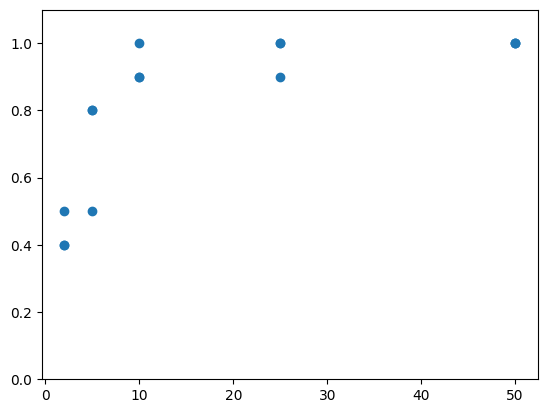

In [6]:
plt.plot(disc_dim_arr, disc_dim_acc_arr,'o')
plt.ylim([-0.0,1.1])

In [7]:
varying_disc_dims_df = pd.DataFrame([disc_dim_arr, disc_dim_acc_arr, distance_method]).T
varying_disc_dims_df.columns = ['dimensions', 'sublabel_accuracy', 'distance_method']
varying_disc_dims_df.to_csv('data/discriminatory_dims_sublabel_accuracy_012725.csv')

In [2]:
varying_disc_dims_df = pd.read_csv('data/discriminatory_dims_sublabel_accuracy_012725.csv')

In [3]:
varying_disc_dims_df

,Unnamed: 0,dimensions,sublabel_accuracy,distance_method
0,0,2.0,0.4,e
1,1,2.0,0.4,u
2,2,2.0,0.5,c
3,3,5.0,0.8,l
4,4,5.0,0.5,i
5,5,5.0,0.8,d
6,6,10.0,0.9,e
7,7,10.0,1.0,a
8,8,10.0,0.9,n
9,9,25.0,1.0,NaN


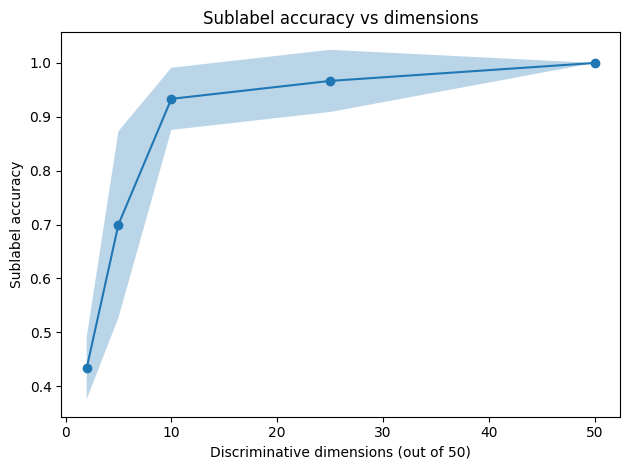

In [15]:
plt.title("Sublabel accuracy vs dimensions")
plt.xlabel("Discriminative dimensions (out of 50)")
plt.ylabel("Sublabel accuracy")
plot_mean_std(varying_disc_dims_df, x='dimensions', y='sublabel_accuracy')


### Adding noise dimensions

In [2]:
def generate_point_clouds_subpops(
    N, P, M, A=1.0, B=1.0, seed=None, eps=1e-6,
    P_disc=0, SP=1, disc_pops=None, discriminative_strength=4.0,
    noise_dims=None
):
    """
    Generate N Gaussian point clouds (N, P, M) with optional subpopulations
    and optional "noise dimensions" that are shared (same mean & variance)
    across all populations.

    Parameters (new/important):
    - noise_dims: None (default), an integer (count) or an iterable of indices.
        * If int > 0: select that many noise dims from the first dims after P_disc.
        * If iterable: used as indices directly (will be sanitized).
        For each noise-dimension we choose one shared mean and one shared variance,
        and force all populations to have that mean & variance (and zero cross-covariances)
        on those dimensions.

    Returns:
      clouds:        (N, P, M)
      means:         (N, M)
      covs:          (N, M, M)
      pop_labels:    (N, P)
      subpop_labels: (N, P)
      disc_dims:     (P_disc,)
      disc_pops:     sorted np.ndarray of discriminative population indices
      noise_dims:    sorted np.ndarray of noise dimension indices (possibly empty)
      shared_noise_means: (len(noise_dims),) array of chosen shared means
      shared_noise_vars:  (len(noise_dims),) array of chosen shared variances (not std)
    """
    rng = np.random.default_rng(seed)

    # sanitize basic inputs
    N = int(N); P = int(P); M = int(M)
    P_disc = int(min(max(P_disc, 0), M))
    SP = int(max(SP, 1))
    discriminative_strength = float(discriminative_strength)

    disc_dims = np.arange(P_disc)

    # disc_pops sanitization
    if disc_pops is None:
        disc_pops = np.arange(N, dtype=int)
    else:
        disc_pops = np.asarray(disc_pops, dtype=int)
        disc_pops = disc_pops[(disc_pops >= 0) & (disc_pops < N)]
        disc_pops = np.unique(disc_pops)
    disc_pops = np.sort(disc_pops)
    disc_pops_set = set(disc_pops.tolist())

    # ---------- noise_dims handling ----------
    # normalize noise_dims input into an array of indices (possibly empty)
    if noise_dims is None:
        noise_dims_idx = np.array([], dtype=int)
    elif isinstance(noise_dims, (int, np.integer)):
        n_noise = int(noise_dims)
        if n_noise <= 0:
            noise_dims_idx = np.array([], dtype=int)
        else:
            # pick the first n_noise dims after P_disc (but within M)
            start = P_disc
            available = np.arange(start, M)
            if n_noise > available.size:
                raise ValueError("Requested more noise_dims than available dimensions")
            noise_dims_idx = np.array(available[:n_noise], dtype=int)
    else:
        # treat as iterable of indices
        noise_dims_idx = np.unique(np.asarray(list(noise_dims), dtype=int))
        # sanitize range
        noise_dims_idx = noise_dims_idx[(noise_dims_idx >= 0) & (noise_dims_idx < M)]
        # also avoid overlapping with discriminative dims (disc_dims = 0..P_disc-1)
        # (But if user explicitly specified overlap, we'll still remove duplicates)
        noise_dims_idx = noise_dims_idx[~np.isin(noise_dims_idx, disc_dims)]

    noise_dims_idx = np.sort(noise_dims_idx)
    n_noise = noise_dims_idx.size

    # ---------- sample shared noise means & variances ----------
    # If there are noise dims, choose a single shared mean (Uniform[-A,A]) and
    # a single shared variance for each noise dim. We'll obtain variances by
    # creating one random SPD matrix (same procedure used for pop covs) and use
    # its diagonal elements for the noise dims (times B and plus eps).
    if n_noise > 0:
        # shared means for noise dims
        shared_noise_means = A * 2.0 * (rng.random(n_noise) - 0.5)

        # create one random SPD to get realistic per-dim variances
        R_tmp = rng.standard_normal((M, M))
        cov_tmp = (R_tmp @ R_tmp.T) / max(1, M)
        cov_tmp = B * cov_tmp + eps * np.eye(M)
        shared_noise_vars = np.maximum(np.diag(cov_tmp)[noise_dims_idx], eps)
    else:
        shared_noise_means = np.array([], dtype=float)
        shared_noise_vars = np.array([], dtype=float)

    # ---------- prepare base means & covs ----------
    means = A * 2.0 * (rng.random((N, M)) - 0.5)

    covs = np.empty((N, M, M))
    clouds = np.empty((N, P, M))

    pop_labels = np.repeat(np.arange(N)[:, None], P, axis=1)
    subpop_labels = np.zeros((N, P), dtype=int)

    # first non-discriminative population reference (for signed bias)
    non_disc = [j for j in range(N) if j not in disc_pops_set]
    ref_pop = non_disc[0] if non_disc else None
    # bias dimension: first non-discriminative dimension (if exists)
    bias_dim = P_disc if P_disc < M else None

    disc_pops_set = set(disc_pops.tolist())

    for i in range(N):
        # create random SPD covariance for this population
        R = rng.standard_normal((M, M))
        cov = (R @ R.T) / max(1, M)
        cov = B * cov + eps * np.eye(M)

        # overwrite noise-dim covariances so noise dims are independent and share the same variance
        if n_noise > 0:
            # zero out cross-covariances involving noise dims
            for d in noise_dims_idx:
                cov[d, :] = 0.0
                cov[:, d] = 0.0
                cov[d, d] = shared_noise_vars[np.where(noise_dims_idx == d)[0][0]]

        covs[i] = cov

        # ensure means for noise dims are shared
        if n_noise > 0:
            means[i, noise_dims_idx] = shared_noise_means

        # sample baseline points with this mean/cov
        L = np.linalg.cholesky(cov)
        Z = rng.standard_normal((P, M))
        base = means[i] + Z @ L.T

        # apply subpopulation structure to discriminative populations
        if (P_disc > 0) and (SP > 1) and (i in disc_pops_set):
            sub = (np.arange(P) % SP) + 1
            rng.shuffle(sub)
            subpop_labels[i] = sub

            std = np.sqrt(np.diag(cov))
            centers = (sub - (SP + 1) / 2.0)

            offsets = np.zeros((P, M))
            offsets[:, disc_dims] = centers[:, None] * (discriminative_strength * std[disc_dims])[None, :]

            # signed adjustment so sub==1 moves toward ref_pop along bias_dim
            if (ref_pop is not None) and (bias_dim is not None):
                delta = means[ref_pop, bias_dim] - means[i, bias_dim]
                sign = 1.0 if delta >= 0 else -1.0
                offsets[sub == 1, bias_dim] += sign * discriminative_strength * std[bias_dim]

            clouds[i] = base + offsets
        else:
            clouds[i] = base

    return (clouds, means, covs,
            pop_labels, subpop_labels)


In [35]:
def resample_point_clouds_subpops(
    means, covs, P, seed=None,
    P_disc=0, SP=1, disc_pops=None,
    discriminative_strength=4,
    noise_dims=None,
    shared_noise_means=None,
    shared_noise_vars=None
):
    """
    Resample clouds from stored means/covs, optionally re-imposing subpopulations,
    and optionally enforcing "noise dimensions" so those dims have the same mean
    and variance across all populations.

    New parameters:
    - noise_dims: None, int, or iterable of indices (same semantics as in generator).
    - shared_noise_means: optional array of length n_noise to force exact shared mean.
      If None and noise_dims is provided, we will derive shared means from `means` by averaging across populations.
    - shared_noise_vars: optional array of length n_noise to force exact shared variance.
      If None and noise_dims is provided, we will derive shared variances from `covs` by averaging the diag variances across populations.

    Returns:
      clouds: (N, P, M)
      pop_labels, subpop_labels
    """
    rng = np.random.default_rng(seed)

    means = np.asarray(means, float)
    covs = np.asarray(covs, float)

    N, M = means.shape
    if N == 0:
        return np.empty((0, 0, M)), np.empty((0, 0), dtype=int), np.empty((0, 0), dtype=int)

    # sanitize inputs
    P_disc = int(min(max(int(P_disc), 0), M))
    SP = int(max(int(SP), 1))
    discriminative_strength = float(discriminative_strength)
    disc_dims = np.arange(P_disc)

    # disc_pops sanitization
    if disc_pops is None:
        disc_pops = np.arange(N, dtype=int)
    else:
        disc_pops = np.unique(np.asarray(disc_pops, dtype=int))
        disc_pops = disc_pops[(disc_pops >= 0) & (disc_pops < N)]
    disc_pops = np.sort(disc_pops)
    disc_set = set(disc_pops.tolist())

    # ---------- noise_dims handling (same logic as generator) ----------
    if noise_dims is None:
        noise_dims_idx = np.array([], dtype=int)
    elif isinstance(noise_dims, (int, np.integer)):
        n_noise = int(noise_dims)
        if n_noise <= 0:
            noise_dims_idx = np.array([], dtype=int)
        else:
            start = P_disc
            available = np.arange(start, M)
            if n_noise > available.size:
                raise ValueError("Requested more noise_dims than available dimensions")
            noise_dims_idx = np.array(available[:n_noise], dtype=int)
    else:
        noise_dims_idx = np.unique(np.asarray(list(noise_dims), dtype=int))
        noise_dims_idx = noise_dims_idx[(noise_dims_idx >= 0) & (noise_dims_idx < M)]
        noise_dims_idx = noise_dims_idx[~np.isin(noise_dims_idx, disc_dims)]
    noise_dims_idx = np.sort(noise_dims_idx)
    n_noise = noise_dims_idx.size

    # if noise dims present and shared means/vars not provided, derive them
    if n_noise > 0:
        if shared_noise_means is None:
            # derive a shared mean by averaging the per-population means
            shared_noise_means = means[:, noise_dims_idx].mean(axis=0)
        else:
            shared_noise_means = np.asarray(shared_noise_means, float)
            if shared_noise_means.shape[0] != n_noise:
                raise ValueError("shared_noise_means length mismatch with noise_dims")

        if shared_noise_vars is None:
            # derive shared variance by averaging diagonal variances across populations
            per_pop_vars = np.asarray([np.diag(cov)[noise_dims_idx] for cov in covs])
            shared_noise_vars = per_pop_vars.mean(axis=0)
        else:
            shared_noise_vars = np.asarray(shared_noise_vars, float)
            if shared_noise_vars.shape[0] != n_noise:
                raise ValueError("shared_noise_vars length mismatch with noise_dims")
    else:
        shared_noise_means = np.array([], dtype=float)
        shared_noise_vars = np.array([], dtype=float)

    # apply the shared noise constraints to the given means/covs (in a copy, don't mutate inputs)
    means_c = means.copy()
    covs_c = covs.copy()
    if n_noise > 0:
        for d_idx, d in enumerate(noise_dims_idx):
            means_c[:, d] = shared_noise_means[d_idx]
            # zero cross-covariances and set diag to shared var
            for i in range(N):
                covs_c[i, d, :] = 0.0
                covs_c[i, :, d] = 0.0
                covs_c[i, d, d] = max(shared_noise_vars[d_idx], 1e-12)

    # now we can resample as before but using means_c and covs_c
    clouds = np.empty((N, P, M))
    pop_labels = np.repeat(np.arange(N)[:, None], P, axis=1)
    subpop_labels = np.zeros((N, P), dtype=int)

    # reference population and bias dim, for signed bias
    non_disc = [j for j in range(N) if j not in disc_set]
    ref_pop = non_disc[0] if non_disc else None
    bias_dim = P_disc if P_disc < M else None

    use_subpops = (P_disc > 0) and (SP > 1)

    for i in range(N):
        L = np.linalg.cholesky(covs_c[i])
        Z = rng.standard_normal((P, M))
        base = means_c[i] + Z @ L.T

        if use_subpops and (i in disc_set):
            sub = (np.arange(P) % SP) + 1
            rng.shuffle(sub)
            subpop_labels[i] = sub

            std = np.sqrt(np.diag(covs_c[i]))
            centers = (sub - (SP + 1) / 2.0)
            offsets = np.zeros((P, M))
            offsets[:, disc_dims] = centers[:, None] * (discriminative_strength * std[disc_dims])[None, :]

            if (ref_pop is not None) and (bias_dim is not None):
                delta = means_c[ref_pop, bias_dim] - means_c[i, bias_dim]
                sign = 1.0 if delta >= 0 else -1.0
                offsets[sub == 1, bias_dim] += sign * discriminative_strength * std[bias_dim]

            clouds[i] = base + offsets
        else:
            clouds[i] = base

    return clouds, pop_labels, subpop_labels


In [44]:
num_clouds = 5
num_points_per_cloud = 20
num_dims = 50
num_disc_dims = 30

In [45]:
clouds1, means1, covs1, poplabels1, sublabels1 = generate_point_clouds_subpops(num_clouds, 
                                                                               num_points_per_cloud, 
                                                                               num_dims, 
                                                                               A=2, 
                                                                               B=0.5, 
                                                                               P_disc=num_disc_dims, 
                                                                               SP=2, 
                                                                               disc_pops=[0],
                                                                               discriminative_strength=2,
                                                                               noise_dims=10)

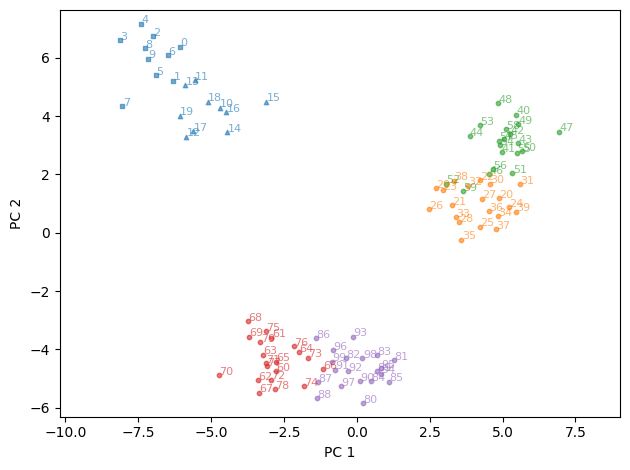

In [46]:
plot_first_two_dims(clouds1, sublabels=sublabels1, annotate=True, pca=True)

In [53]:
noise_dim_arr = []
noise_dim_acc_arr = []
noise_dim_sublabel_acc_arr = []
disc_dims = 10
for distance_method in ['euclidean']:
    for noise_dims in [0,10,20,30,40]:
        fully_paired_examples = 0
        while fully_paired_examples < 3:
            clouds1, means1, covs1, poplabels1, sublabels1 = generate_point_clouds_subpops(num_clouds, 
                                                                                       num_points_per_cloud, 
                                                                                       num_dims, 
                                                                                       A=2, 
                                                                                       B=0.5, 
                                                                                       P_disc=disc_dims, 
                                                                                       SP=2, 
                                                                                       disc_pops=[0],
                                                                                       discriminative_strength=2,
                                                                                       noise_dims=noise_dims)
            clouds2, poplabels2, sublabels2 = resample_point_clouds_subpops(means1, covs1, num_points_per_cloud,
                                                                    P_disc=disc_dims, SP=2, disc_pops=[0],
                                                                    discriminative_strength=2,
                                                                    noise_dims=noise_dims)
            cloud_coords1, labels1 = flatten_clouds(clouds1)
            cloud_coords2, labels2 = flatten_clouds(clouds2)

            gw = run_ot(cloud_coords1, cloud_coords2, num_clouds * num_points_per_cloud, 
                        distance_method=distance_method)

            acc = compute_mapping_acc(gw, labels1, labels2)

            print(acc)

            if acc > 0.7:
                fully_paired_examples += 1

                sublabel_acc = sublabel_match_rate_from_gw(gw, labels1, labels2, sublabels1, sublabels2)

                noise_dim_arr.append(noise_dims)
                noise_dim_acc_arr.append(acc)
                noise_dim_sublabel_acc_arr.append(sublabel_acc)
    

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


1.0
1.0
1.0
1.0
1.0
0.4
0.6
0.6
0.6
0.4
1.0
1.0
1.0
1.0
1.0
0.0
1.0
0.98
0.84
0.25
0.74
0.09
0.41
0.66
0.92


In [54]:
varying_noise_dims_df = pd.DataFrame([noise_dim_arr, noise_dim_acc_arr, noise_dim_sublabel_acc_arr]).T
varying_noise_dims_df.columns = ['noise_dimensions', 'accuracy', 'sublabel_accuracy']
varying_noise_dims_df.to_csv('data/noise_dims_sublabel_accuracy_012825.csv')

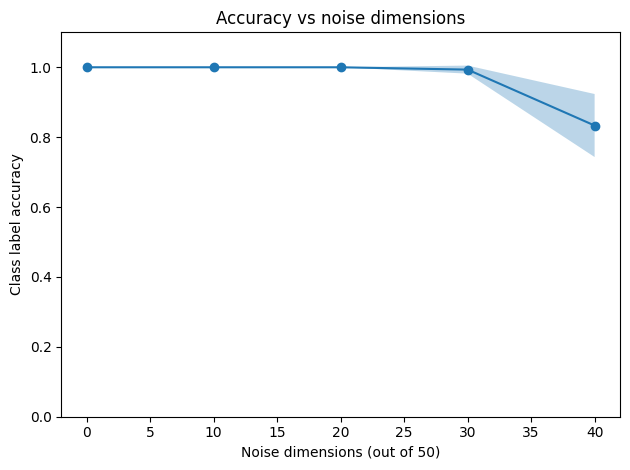

In [60]:
plt.title("Accuracy vs noise dimensions")
plt.xlabel("Noise dimensions (out of 50)")
plt.ylabel("Class label accuracy")
plt.ylim([0,1.1])
plot_mean_std(varying_noise_dims_df, x='noise_dimensions', y='accuracy')

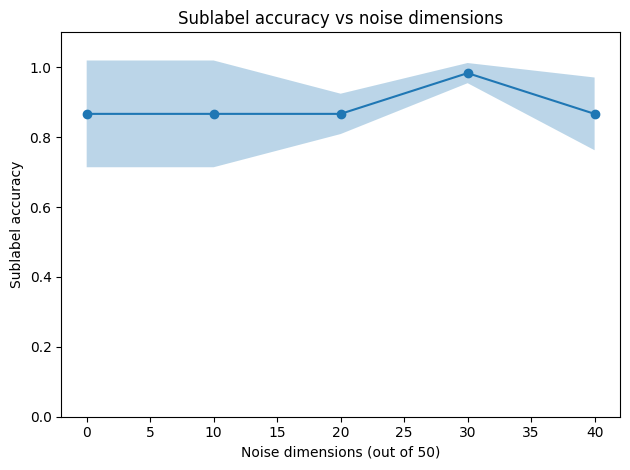

In [59]:
plt.title("Sublabel accuracy vs noise dimensions")
plt.xlabel("Noise dimensions (out of 50)")
plt.ylabel("Sublabel accuracy")
plt.ylim([0,1.1])
plot_mean_std(varying_noise_dims_df, x='noise_dimensions', y='sublabel_accuracy')

Text(0, 0.5, 'Dimension 50')

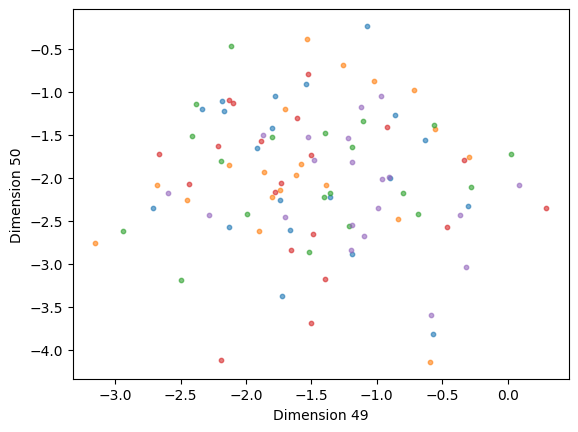

In [63]:
for cloud in clouds1:
    plt.scatter(cloud[:, 48], cloud[:, 49], s=10, alpha=0.6)
plt.xlabel('Dimension 49')
plt.ylabel('Dimension 50')